# 🛠️ Vector GIS Tool: Clip, Reproject & Convert to GeoPackage (`.gpkg`)
**Kernel**: `HydroMT-SFINCS` (`env-sfincs`)

A universal utility notebook to preprocess any vector dataset (Roads, Land Cover, Rivers, Admin Boundaries, Infrastructure, etc.) across different coordinate systems (ESRI Shapefile `.shp`, GeoPackage `.gpkg`, GeoJSON):
1. **CRS-Aware Spatial Bounding Filter**: Automatically matches and transforms the Area of Interest (AoI) into the source file's native coordinate system (e.g. `EPSG:4326` vs `EPSG:32747`), preventing empty/missing outputs.
2. **Clean Geometry Slicing & Preservation**: Supports Polygons, LineStrings (Roads/Rivers), and Points without geometry loss.
3. **Metric On-the-Fly Reprojection**: Accurately projects geometries to your target metric CRS (e.g. `EPSG:32747` UTM Zone 47S).
4. **Standardized OGC GeoPackage Output**: Compact, indexed `.gpkg` layer ready for flood modeling and GIS analysis.

---

## 📌 Step 1 — User Configuration Control Panel

In [6]:
# ==============================================================================
# 1. INPUT VECTOR DATASET (SHP, GPKG, GeoJSON, etc.)
# ==============================================================================
INPUT_VECTOR_PATH = "temp/shp/Export_Output.shp"  # your road .shp / .gpkg path
AOI_VECTOR_PATH   = "data/das_clusters.gpkg"
AOI_FILTER_COLUMN = None
AOI_FILTER_VALUE  = None               # or your desired DAS/Kabupaten
TARGET_CRS        = "EPSG:32747"
OUTPUT_GPKG_PATH  = "data/roads.gpkg"
OUTPUT_LAYER_NAME = "roads"

print("✅ Configuration defined successfully!")
print(f"📂 Input Vector  : {INPUT_VECTOR_PATH}")
print(f"🎯 AoI Boundary : {AOI_VECTOR_PATH} (Filter: {AOI_FILTER_COLUMN}={AOI_FILTER_VALUE})")
print(f"🗺️ Target CRS    : {TARGET_CRS}")
print(f"💾 Output GPKG   : {OUTPUT_GPKG_PATH} (Layer: {OUTPUT_LAYER_NAME})")

✅ Configuration defined successfully!
📂 Input Vector  : temp/shp/Export_Output.shp
🎯 AoI Boundary : data/das_clusters.gpkg (Filter: None=None)
🗺️ Target CRS    : EPSG:32747
💾 Output GPKG   : data/roads.gpkg (Layer: roads)


---  
## ⚙️ Step 2 — Environment & Library Initialization

In [7]:
# Automatically set working directory to project root
from pathlib import Path
import os, sys
project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root.parent != project_root:
    project_root = project_root.parent
os.chdir(project_root)
if str(project_root / 'scripts') not in sys.path:
    sys.path.insert(0, str(project_root / 'scripts'))

import os
import sys
import time
from pathlib import Path
import geopandas as gpd
import pyproj
import pyogrio
import shapely
from shapely.validation import make_valid
import matplotlib.pyplot as plt

# Fix PROJ and GDAL paths dynamically for active Python environment
site_packages = Path(sys.prefix) / "Lib" / "site-packages"
proj_dir = (site_packages / "rasterio" / "proj_data").resolve()
gdal_dir = (site_packages / "rasterio" / "gdal_data").resolve()
if proj_dir.exists():
    os.environ["PROJ_DATA"] = str(proj_dir)
    os.environ["PROJ_LIB"] = str(proj_dir)
    pyproj.datadir.set_data_dir(str(proj_dir))
if gdal_dir.exists():
    os.environ["GDAL_DATA"] = str(gdal_dir)

print(f"GeoPandas Version : {gpd.__version__}")
print(f"PyOGRIO Version   : {pyogrio.__version__}")
print(f"PyProj Version    : {pyproj.__version__}")

GeoPandas Version : 1.1.4
PyOGRIO Version   : 0.13.0
PyProj Version    : 3.7.2


---  
## 🚀 Step 3 — CRS-Aware Spatial Read, Reproject & Clip

In [8]:
t_start = time.time()

# 1. Load Area of Interest (AoI)
print("⏳ [1/5] Loading and preparing Area of Interest (AoI)...")
aoi_gdf = gpd.read_file(AOI_VECTOR_PATH)

# Auto-detect or filter column
if AOI_FILTER_COLUMN and AOI_FILTER_VALUE is not None:
    val_str = str(AOI_FILTER_VALUE).replace("DAS_", "").strip()
    if AOI_FILTER_COLUMN in aoi_gdf.columns:
        mask = aoi_gdf[AOI_FILTER_COLUMN].astype(str).str.replace("DAS_", "").str.strip() == val_str
        aoi_gdf = aoi_gdf[mask].copy()
    else:
        # Check fallback column names
        for alt_col in ["ID_Cluster", "das_id", "NAMOBJ", "WADMKK"]:
            if alt_col in aoi_gdf.columns:
                mask = aoi_gdf[alt_col].astype(str).str.replace("DAS_", "").str.strip() == val_str
                if mask.any():
                    aoi_gdf = aoi_gdf[mask].copy()
                    print(f"   Matched filter using column '{alt_col}'")
                    break

if aoi_gdf.empty:
    raise ValueError(f"AoI filtering resulted in 0 features! Check '{AOI_FILTER_COLUMN}={AOI_FILTER_VALUE}'")

# Project AoI to metric TARGET_CRS to compute buffer in meters
if aoi_gdf.crs != TARGET_CRS:
    aoi_gdf = aoi_gdf.to_crs(TARGET_CRS)

# Apply buffer margin in meters if requested
if AOI_BUFFER_METERS > 0:
    print(f"   Applying +{AOI_BUFFER_METERS}m buffer to AoI boundary...")
    aoi_buffered_geom = aoi_gdf.geometry.buffer(AOI_BUFFER_METERS)
    aoi_gdf = gpd.GeoDataFrame(geometry=aoi_buffered_geom, crs=TARGET_CRS)

aoi_union = aoi_gdf.geometry.union_all() if hasattr(aoi_gdf.geometry, 'union_all') else aoi_gdf.geometry.unary_union
print(f"   AoI Extent (in {TARGET_CRS}): {[round(x, 1) for x in aoi_gdf.total_bounds]}")

# 2. Inspect Source Vector CRS & Prepare Native Bounding Filter
print("⏳ [2/5] Inspecting source vector metadata & CRS...")
try:
    info = pyogrio.read_info(INPUT_VECTOR_PATH, layer=INPUT_LAYER_NAME)
    source_crs = info.get("crs")
except Exception as e:
    source_crs = None

if not source_crs:
    source_crs = FALLBACK_INPUT_CRS
    print(f"   ⚠️ No CRS found in source vector, using fallback: {source_crs}")
else:
    print(f"   Source CRS detected: {source_crs}")

# Transform AoI bounding box to the source file's native CRS
try:
    aoi_in_source_crs = aoi_gdf.to_crs(source_crs)
    read_bbox = tuple(aoi_in_source_crs.total_bounds)
    print(f"   Transformed bounding filter (in {source_crs}): {[round(x, 4) for x in read_bbox]}")
except Exception:
    read_bbox = None
    print("   Could not transform bbox, loading full layer...")

# 3. Read Source Vector with Native Bbox Filter
print("⏳ [3/5] Reading input features...")
try:
    if read_bbox:
        input_gdf = gpd.read_file(INPUT_VECTOR_PATH, layer=INPUT_LAYER_NAME, bbox=read_bbox)
    else:
        input_gdf = gpd.read_file(INPUT_VECTOR_PATH, layer=INPUT_LAYER_NAME)
except Exception as e:
    print(f"   Bbox read failed ({e}), falling back to full read...")
    input_gdf = gpd.read_file(INPUT_VECTOR_PATH, layer=INPUT_LAYER_NAME)

if input_gdf.empty:
    print("   ⚠️ Bbox read returned 0 features, attempting full file read as safety fallback...")
    input_gdf = gpd.read_file(INPUT_VECTOR_PATH, layer=INPUT_LAYER_NAME)

if input_gdf.crs is None:
    input_gdf.set_crs(source_crs, inplace=True)

print(f"   Loaded {len(input_gdf):,} features from source (Geometry: {input_gdf.geom_type.unique().tolist()})")

# 4. Reproject Features to Target Metric CRS
print(f"⏳ [4/5] Reprojecting features to {TARGET_CRS}...")
if input_gdf.crs != TARGET_CRS:
    input_gdf = input_gdf.to_crs(TARGET_CRS)

# 5. Execute Geometry Repair & Clipping Mode
print(f"⏳ [5/5] Executing clipping mode: '{CLIP_MODE}'...")
# Repair invalid geometries
input_gdf["geometry"] = input_gdf["geometry"].apply(lambda g: make_valid(g) if (g is not None and not g.is_valid) else g)

if CLIP_MODE == "exact_clip":
    # keep_geom_type=False ensures clipped lines/polygons are not dropped
    clipped_gdf = gpd.clip(input_gdf, aoi_gdf, keep_geom_type=False)
elif CLIP_MODE == "intersects":
    clipped_gdf = input_gdf[input_gdf.intersects(aoi_union)].copy()
elif CLIP_MODE == "bbox_only":
    minx, miny, maxx, maxy = aoi_gdf.total_bounds
    clipped_gdf = input_gdf.cx[minx:maxx, miny:maxy].copy()
else:
    raise ValueError(f"Unknown CLIP_MODE: {CLIP_MODE}")

# Explode multipart collections if any exist and filter empty geometries
clipped_gdf = clipped_gdf[~clipped_gdf.is_empty & clipped_gdf.geometry.notnull()].copy()

# 6. Write directly to GeoPackage (.gpkg)
out_p = Path(OUTPUT_GPKG_PATH).resolve()
out_p.parent.mkdir(parents=True, exist_ok=True)
clipped_gdf.to_file(str(out_p), layer=OUTPUT_LAYER_NAME, driver="GPKG")

elapsed = time.time() - t_start
out_size_mb = out_p.stat().st_size / (1024 * 1024) if out_p.exists() else 0

print("\n" + "=" * 80)
print("✅ CONVERSION & CLIPPING COMPLETED SUCCESSFULLY!")
print(f"⏱️ Elapsed Time       : {elapsed:.2f} seconds")
print(f"📊 Source Features    : {len(input_gdf):,} records")
print(f"📊 Clipped Features   : {len(clipped_gdf):,} records")
print(f"📦 Output GeoPackage  : {out_p}")
print(f"💾 Output File Size   : {out_size_mb:.2f} MB")
print(f"🗺️ Coordinate System  : {clipped_gdf.crs}")
print("=" * 80)

⏳ [1/5] Loading and preparing Area of Interest (AoI)...
   Applying +1000.0m buffer to AoI boundary...
   AoI Extent (in EPSG:32747): [np.float64(454110.2), np.float64(9628703.0), np.float64(1105198.7), np.float64(10245010.5)]
⏳ [2/5] Inspecting source vector metadata & CRS...
   Source CRS detected: EPSG:4326
   Transformed bounding filter (in EPSG:4326): [np.float64(98.5875), np.float64(-3.3581), np.float64(104.4319), np.float64(2.2154)]
⏳ [3/5] Reading input features...
   Loaded 708,477 features from source (Geometry: ['LineString', 'MultiLineString'])
⏳ [4/5] Reprojecting features to EPSG:32747...
⏳ [5/5] Executing clipping mode: 'exact_clip'...

✅ CONVERSION & CLIPPING COMPLETED SUCCESSFULLY!
⏱️ Elapsed Time       : 6380.81 seconds
📊 Source Features    : 708,477 records
📊 Clipped Features   : 415,385 records
📦 Output GeoPackage  : D:\Project\sumbar_flood_hazard\data\roads.gpkg
💾 Output File Size   : 295.26 MB
🗺️ Coordinate System  : EPSG:32747


---  
## 🔍 Step 4 — Attribute Table Inspection & Summary

In [9]:
if len(clipped_gdf) > 0:
    print("=== Attribute Table Summary ===")
    print(f"Geometry Types: {clipped_gdf.geom_type.value_counts().to_dict()}")
    print("\nFirst 5 Records:")
    display(clipped_gdf.drop(columns=["geometry"]).head(5))
    
    for col in ["REMARK", "NAMOBJ", "fungsi", "kelas", "fclass", "tipe"]:
        if col in clipped_gdf.columns:
            print(f"\nTop Classes in '{col}':")
            print(clipped_gdf[col].value_counts().head(10))
            break
else:
    print("⚠️ Warning: 0 records found in the clipped dataset. Please verify the AoI filter and spatial extent.")

=== Attribute Table Summary ===
Geometry Types: {'LineString': 414816, 'MultiLineString': 533, 'Point': 36}

First 5 Records:


,OBJECTID,NAMRJL,KONRJL,MATRJL,FGSRJL,UTKRJL,TOLRJL,WLYRJL,AUTRJL,KLSRJL,...,KLLRJL,MEDRJL,LOCRJL,JARRJL,FCODE,REMARK,SRS_ID,LCODE,METADATA,SHAPE_Leng
111468,357015,None,0,0,0,0,0,0,0,0,...,None,0,0,0,None,Jalan Lain,None,CA0080,None,0.053475
111509,357065,None,0,0,0,0,0,0,0,0,...,None,0,0,0,None,Jalan Lain,None,CA0080,None,0.030777
87857,330575,None,0,0,0,0,0,0,0,0,...,None,0,0,0,None,Jalan Lain,None,CA0080,None,0.017931
74375,315937,None,0,0,0,0,0,0,0,0,...,None,0,0,0,None,Jalan Lain,None,CA0080,None,0.034275
94374,337619,None,0,0,0,0,0,0,0,0,...,None,0,0,0,None,Jalan Lain,None,CA0080,None,0.008654



Top Classes in 'REMARK':
REMARK
Jalan Lain        395221
Jalan Lokal        19839
Jalan Kolektor       182
Jalan Arteri         143
Name: count, dtype: int64


---  
## 🗺️ Step 5 — Visual Quality Assurance (QA/QC Map Preview)

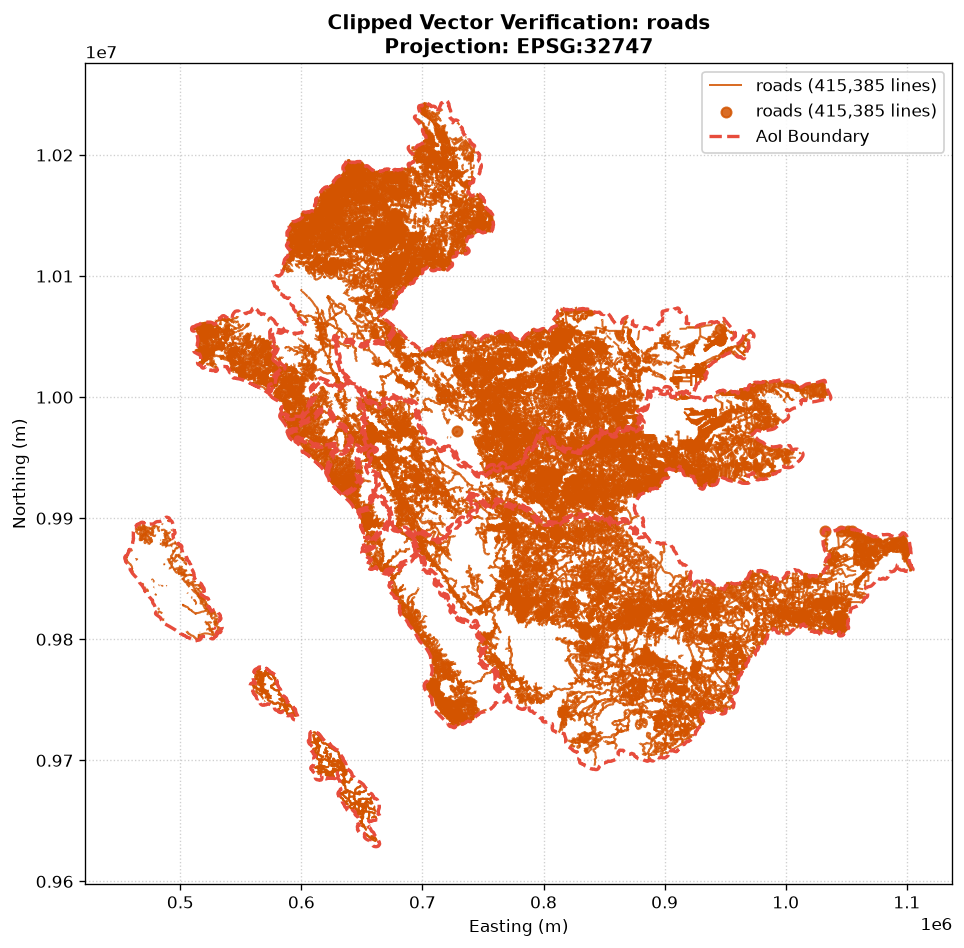

In [10]:
if len(clipped_gdf) > 0:
    fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
    
    # Determine styling based on geometry type
    first_geom = clipped_gdf.geom_type.iloc[0]
    if "Line" in first_geom:
        clipped_gdf.plot(ax=ax, color="#D35400", linewidth=1.2, alpha=0.85, label=f"{OUTPUT_LAYER_NAME} ({len(clipped_gdf):,} lines)")
    elif "Point" in first_geom:
        clipped_gdf.plot(ax=ax, color="#8E44AD", markersize=15, alpha=0.85, label=f"{OUTPUT_LAYER_NAME} ({len(clipped_gdf):,} points)")
    else:
        clipped_gdf.plot(ax=ax, color="#3498DB", edgecolor="#2980B9", linewidth=0.6, alpha=0.65, label=f"{OUTPUT_LAYER_NAME} ({len(clipped_gdf):,} polygons)")
    
    # Plot AoI Boundary Overlay
    aoi_gdf.boundary.plot(ax=ax, color="#E74C3C", linewidth=2.0, linestyle="--", label="AoI Boundary")
    
    ax.set_title(f"Clipped Vector Verification: {OUTPUT_LAYER_NAME}\nProjection: {TARGET_CRS}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Easting (m)", fontsize=10)
    ax.set_ylabel("Northing (m)", fontsize=10)
    ax.legend(loc="upper right", framealpha=0.9)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot map: Clipped layer is empty.")